# Part A — Concept Application 

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## 1. Data Loading & Exploration

In [22]:
df = pd.read_csv('./data/suv_data.csv')

In [15]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510.0,Male,19.0,19000.0,0.0
1,15810944.0,Male,35.0,20000.0,0.0
2,15668575.0,Female,26.0,43000.0,0.0
3,15603246.0,Female,27.0,57000.0,0.0
4,15804002.0,Male,19.0,76000.0,0.0


In [16]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863.0,Female,46.0,41000.0,1.0
396,15706071.0,Male,51.0,23000.0,1.0
397,15654296.0,Female,50.0,20000.0,1.0
398,15755018.0,Male,36.0,33000.0,0.0
399,15594041.0,Female,49.0,36000.0,1.0


In [17]:
df.shape

(400, 5)

In [18]:
df.columns.to_list()

['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    float64
 1   Gender           400 non-null    object 
 2   Age              400 non-null    float64
 3   EstimatedSalary  400 non-null    float64
 4   Purchased        400 non-null    float64
dtypes: float64(4), object(1)
memory usage: 15.8+ KB


In [25]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

## 2. Data Preprocessing

### No need to handle missing values 

### Encode categorical variables (e.g., Gender)


In [27]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

# Alternative using label encoding
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df['Gender'] = le.fit_transform(df['Gender'])

### Select relevant features (Age, EstimatedSalary) and Separate features (X) and target (y)


In [29]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

## 3. Train-Test Split


### Split dataset into training and testing sets (80/20)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Feature Scaling

In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Model Training (Logistic Regression)

### Train Logistic Regression model

In [34]:
model = LogisticRegression()

### Fit model on training data


In [36]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Part B — Stretch Problem

### 1. Prediction

In [37]:
y_pred = model.predict(X_test)

### 2. Accuracy

In [45]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy*100)

Accuracy: 86.0


### 3. Confusion Matrix

In [39]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[50  2]
 [ 9 19]]


### 4. Decision Boundary Visualization

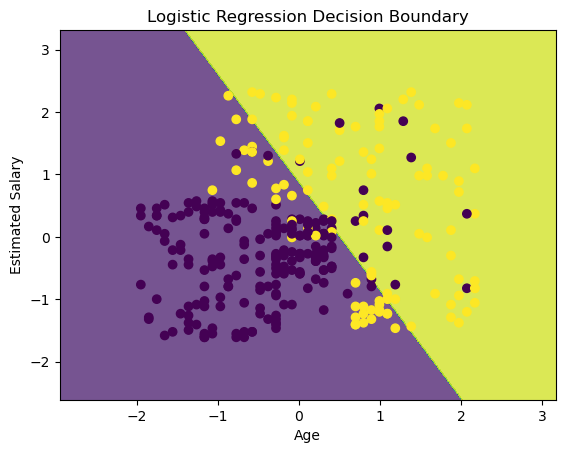

In [ ]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:,0].min()-1, stop=X_set[:,0].max()+1, step=0.01),
    np.arange(start=X_set[:,1].min()-1, stop=X_set[:,1].max()+1, step=0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75
)


plt.scatter(X_set[:,0], X_set[:,1], c=y_set)
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Logistic Regression Decision Boundary')
plt.show()

### 5. Compare Different Test Sizes

### 70/30

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy 70/30:", accuracy_score(y_test, y_pred)*100)

Accuracy 70/30: 85.0


### 75/25

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy 75/25:", accuracy_score(y_test, y_pred)*100)

Accuracy 75/25: 86.0


### 75/25 Split resulted in better accuracy in comparison to 70/30 split